# EDA - checking cleaned data before modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import boto3
import io
import os

s3 = boto3.client('s3')
bucket = 'synchrony-callcenter'

os.makedirs('eda_plots', exist_ok=True)

def load_csv_from_s3(key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

def save_plot_to_s3(local_path, s3_key):
    s3.upload_file(local_path, bucket, s3_key)
    print(f"  -> s3://{bucket}/{s3_key}")

print("ready")

ready


# quick look at all the cleaned files - shapes, columns, dtypes

In [2]:
# load everything up front so i dont have to keep re-reading from s3
daily = {}
interval = {}

for center in ['A', 'B', 'C', 'D']:
    d = load_csv_from_s3(f'processed/center_{center}/daily_clean_{center}.csv')
    d['date'] = pd.to_datetime(d['date'])
    daily[center] = d
    
    iv = load_csv_from_s3(f'processed/center_{center}/interval_merged_{center}.csv')
    iv['datetime'] = pd.to_datetime(iv['datetime'])
    iv['date'] = pd.to_datetime(iv['date'])
    interval[center] = iv
    
    print(f"\nCenter {center}")
    print(f"  daily   : {d.shape} | cols: {list(d.columns)}")
    print(f"  interval: {iv.shape} | cols: {list(iv.columns)}")


Center A
  daily   : (712, 10) | cols: ['date', 'call_volume', 'CCT', 'service_level', 'abandon_rate', 'day_of_week', 'imputed_flag', 'is_weekend', 'is_holiday', 'daily_staffing']
  interval: (4076, 17) | cols: ['service_level', 'call_volume', 'abandoned_calls', 'abandon_rate', 'CCT', 'datetime', 'date', 'day_of_week', 'slot_index', 'imputed_flag', 'is_weekend', 'is_holiday', 'daily_call_volume', 'daily_CCT', 'daily_service_level', 'daily_abandon_rate', 'daily_staffing']

Center B
  daily   : (729, 10) | cols: ['date', 'call_volume', 'CCT', 'service_level', 'abandon_rate', 'day_of_week', 'imputed_flag', 'is_weekend', 'is_holiday', 'daily_staffing']
  interval: (4279, 17) | cols: ['service_level', 'call_volume', 'abandoned_calls', 'abandon_rate', 'CCT', 'datetime', 'date', 'day_of_week', 'slot_index', 'imputed_flag', 'is_weekend', 'is_holiday', 'daily_call_volume', 'daily_CCT', 'daily_service_level', 'daily_abandon_rate', 'daily_staffing']

Center C
  daily   : (724, 10) | cols: ['date

In [13]:
# sanity check - head/tail + dtypes for one center, rest should be same structure
print("Center A daily")
print(daily['A'].head(3).to_string())
print()
print(daily['A'].dtypes)
print(f"\nDate range: {daily['A']['date'].min()} to {daily['A']['date'].max()}")

print("\nCenter A interval")
print(interval['A'].head(3).to_string())
print()
print(interval['A'].describe().round(2))

Center A daily
        date  call_volume     CCT  service_level  abandon_rate  day_of_week  imputed_flag  is_weekend  is_holiday  daily_staffing
0 2024-01-01       2147.0  302.45         0.9855        0.0037            0             0           0           1             NaN
1 2024-01-02       7458.0  349.22         0.5213        0.1136            1             0           0           0             NaN
2 2024-01-03       6882.0  331.07         0.7046        0.0432            2             0           0           0             NaN

date              datetime64[ns]
call_volume              float64
CCT                      float64
service_level            float64
abandon_rate             float64
day_of_week                int64
imputed_flag               int64
is_weekend                 int64
is_holiday                 int64
daily_staffing           float64
dtype: object

Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00

Center A interval
   service_level  call_volume  abandoned_call

# any nulls i should worry about?

In [4]:
for center in ['A', 'B', 'C', 'D']:
    nulls_d = daily[center].isnull().sum()
    nulls_i = interval[center].isnull().sum()
    has_nulls_d = nulls_d[nulls_d > 0]
    has_nulls_i = nulls_i[nulls_i > 0]
    if len(has_nulls_d) > 0 or len(has_nulls_i) > 0:
        print(f"Center {center} has nulls:")
        if len(has_nulls_d) > 0: print(f"  daily: {has_nulls_d.to_dict()}")
        if len(has_nulls_i) > 0: print(f"  interval: {has_nulls_i.to_dict()}")
    else:
        print(f"Center {center}: no nulls")

Center A has nulls:
  daily: {'daily_staffing': 381}
  interval: {'daily_call_volume': 310, 'daily_CCT': 310, 'daily_service_level': 310, 'daily_abandon_rate': 310, 'daily_staffing': 619}
Center B has nulls:
  daily: {'daily_staffing': 399}
  interval: {'daily_staffing': 326}
Center C has nulls:
  daily: {'daily_staffing': 396}
  interval: {'daily_staffing': 336}
Center D has nulls:
  daily: {'daily_staffing': 402}
  interval: {'daily_staffing': 336}


/tmp/ipykernel_8668/3045145078.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['call_volume'].resample('M').mean().reset_index()
/tmp/ipykernel_8668/3045145078.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['call_volume'].resample('M').mean().reset_index()
/tmp/ipykernel_8668/3045145078.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['call_volume'].resample('M').mean().reset_index()
/tmp/ipykernel_8668/3045145078.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['call_volume'].resample('M').mean().reset_index()


  -> s3://synchrony-callcenter/outputs/eda/volume_trend.png


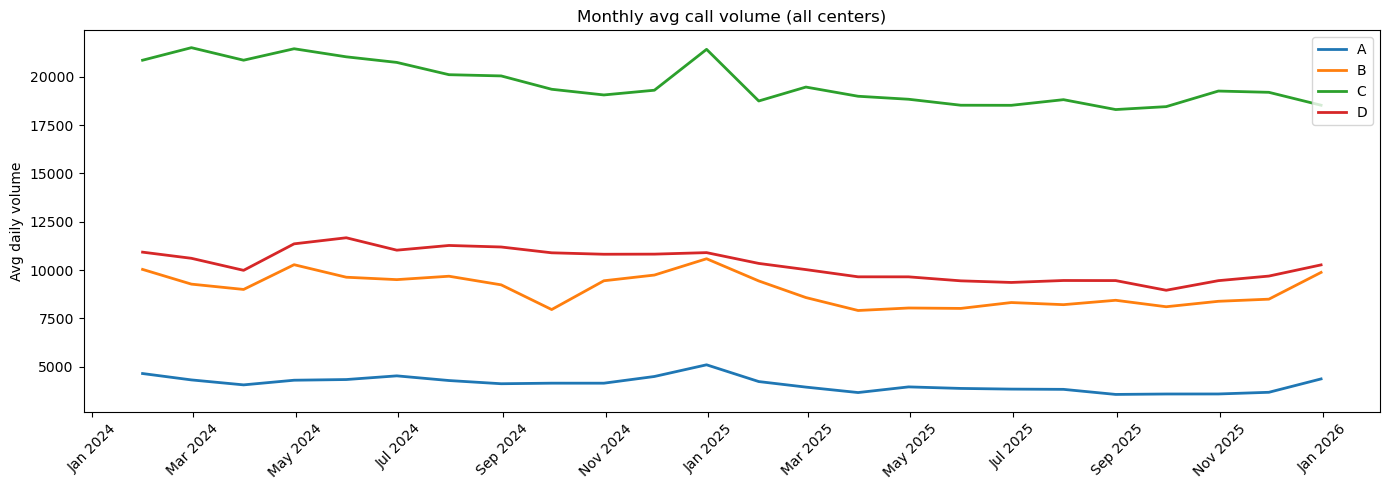

In [5]:
# monthly avg volume trend - smoothed so its not just noise
fig, ax = plt.subplots(figsize=(14, 5))
for center in ['A', 'B', 'C', 'D']:
    df = daily[center]
    monthly = df.set_index('date')['call_volume'].resample('M').mean().reset_index()
    ax.plot(monthly['date'], monthly['call_volume'], label=f'{center}', linewidth=2)

ax.set(title='Monthly avg call volume (all centers)', xlabel='', ylabel='Avg daily volume')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('eda_plots/volume_trend.png', dpi=150)
save_plot_to_s3('eda_plots/volume_trend.png', 'outputs/eda/volume_trend.png')
plt.show()

  -> s3://synchrony-callcenter/outputs/eda/volume_by_dow.png


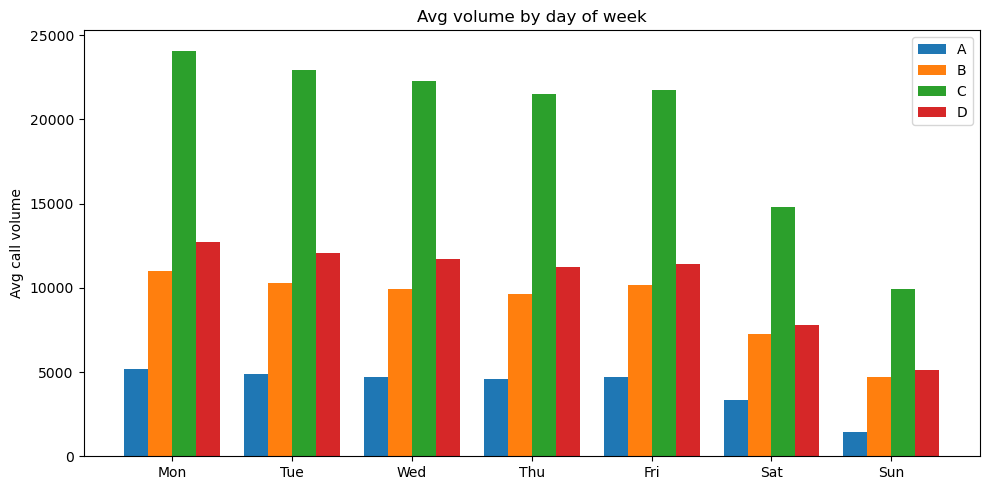

In [6]:
# volume by day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=(10, 5))
x = range(7)
w = 0.2

for i, center in enumerate(['A', 'B', 'C', 'D']):
    dow_avg = daily[center].groupby('day_of_week')['call_volume'].mean()
    offset = (i - 1.5) * w
    ax.bar([p + offset for p in x], dow_avg, width=w, label=center)

ax.set_xticks(list(x))
ax.set_xticklabels(dow_labels)
ax.set(title='Avg volume by day of week', ylabel='Avg call volume')
ax.legend()
plt.tight_layout()
plt.savefig('eda_plots/volume_by_dow.png', dpi=150)
save_plot_to_s3('eda_plots/volume_by_dow.png', 'outputs/eda/volume_by_dow.png')
plt.show()

big drop on weekends for all centers, makes sense. tue-thu seem to be the peak days

# intraday patterns - which 30min slots get the most calls

  -> s3://synchrony-callcenter/outputs/eda/intraday_shape.png


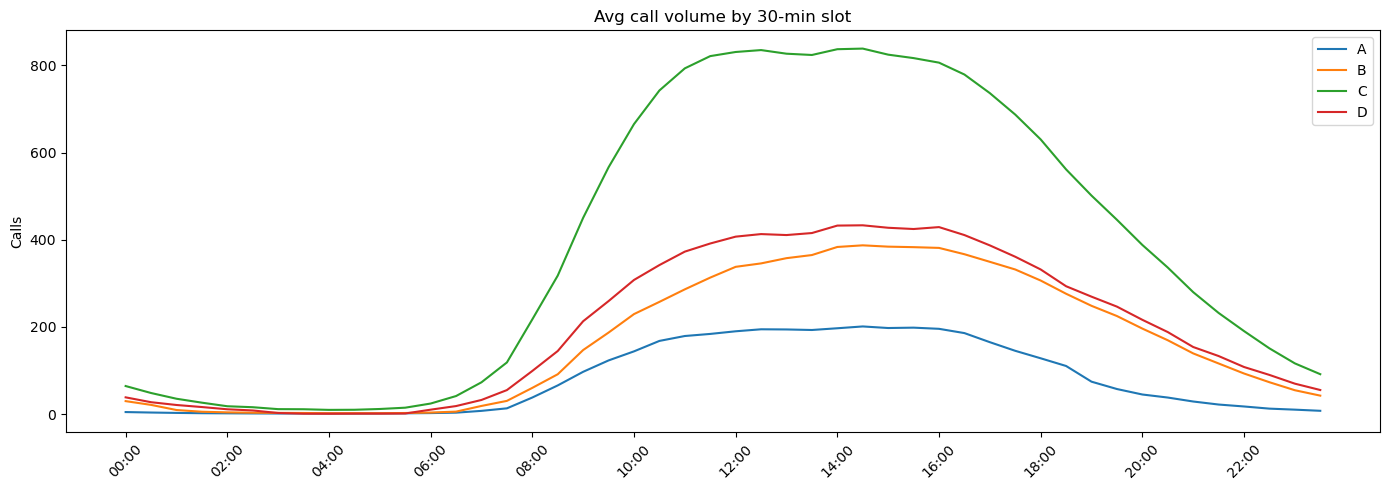

In [7]:
# slot labels for x axis
slot_labels = {i: f"{i//2:02d}:{('30' if i%2 else '00')}" for i in range(48)}
tick_slots = list(range(0, 48, 4))
tick_labels = [slot_labels[i] for i in tick_slots]

# avg volume by slot across all days
fig, ax = plt.subplots(figsize=(14, 5))
for center in ['A','B','C','D']:
    slot_avg = interval[center].groupby('slot_index')['call_volume'].mean()
    ax.plot(slot_avg.index, slot_avg.values, label=center, linewidth=1.5)

ax.set_xticks(tick_slots)
ax.set_xticklabels(tick_labels, rotation=45)
ax.set(title='Avg call volume by 30-min slot', ylabel='Calls')
ax.legend()
plt.tight_layout()
plt.savefig('eda_plots/intraday_shape.png', dpi=150)
save_plot_to_s3('eda_plots/intraday_shape.png', 'outputs/eda/intraday_shape.png')
plt.show()

  -> s3://synchrony-callcenter/outputs/eda/weekday_vs_weekend.png


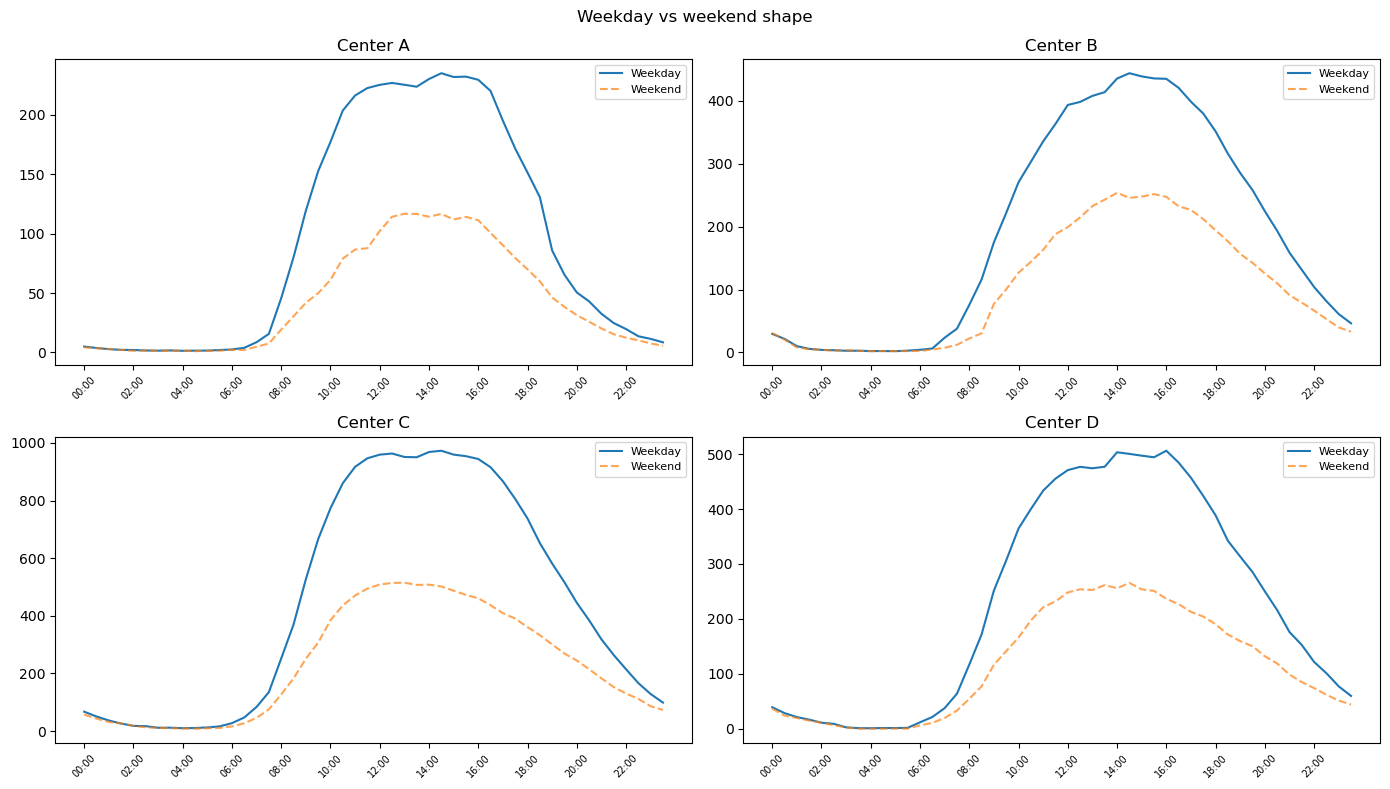

In [8]:
# weekday vs weekend - curious if the shape changes or just the scale
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, center in enumerate(['A','B','C','D']):
    ax = axes.flat[idx]
    df = interval[center]
    wd = df[df['is_weekend']==0].groupby('slot_index')['call_volume'].mean()
    we = df[df['is_weekend']==1].groupby('slot_index')['call_volume'].mean()
    ax.plot(wd.index, wd.values, label='Weekday')
    ax.plot(we.index, we.values, label='Weekend', linestyle='--', alpha=0.7)
    ax.set_title(f'Center {center}')
    ax.set_xticks(tick_slots)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=7)
    ax.legend(fontsize=8)

plt.suptitle('Weekday vs weekend shape')
plt.tight_layout()
plt.savefig('eda_plots/weekday_vs_weekend.png', dpi=150)
save_plot_to_s3('eda_plots/weekday_vs_weekend.png', 'outputs/eda/weekday_vs_weekend.png')
plt.show()

weekend volume is way lower but the shape is similar - peak still around mid-afternoon. good, means slot proportions should be fairly stable across days which helps w/ the modeling approach

# abandon rate - where and why are people hanging up

  -> s3://synchrony-callcenter/outputs/eda/abandon_by_slot.png


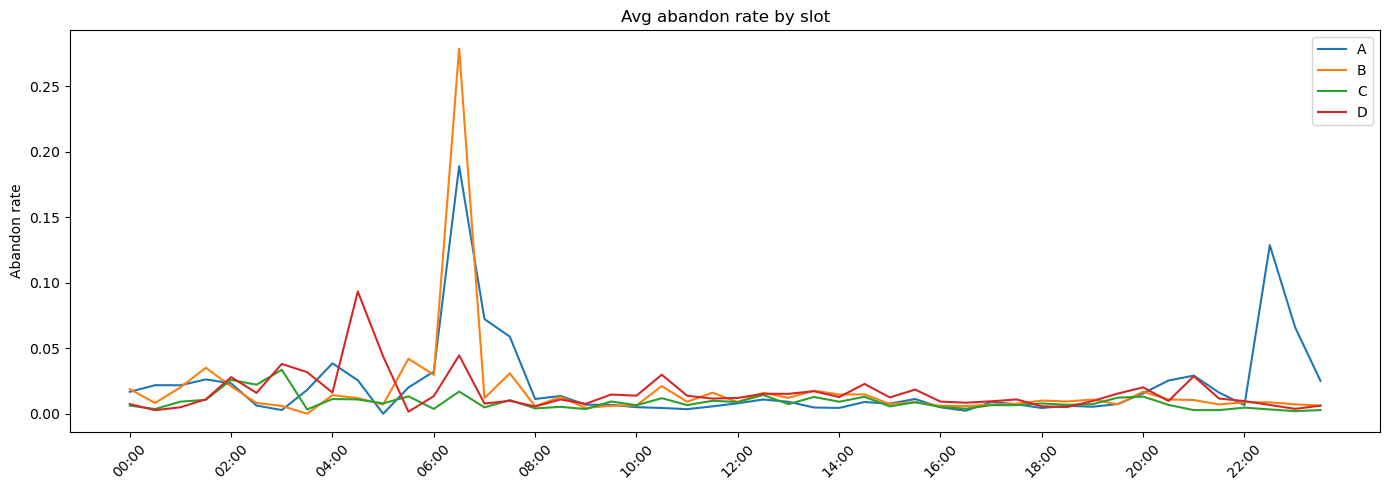

In [9]:
# abandon rate by time of day
fig, ax = plt.subplots(figsize=(14, 5))
for center in ['A','B','C','D']:
    slot_avg = interval[center].groupby('slot_index')['abandon_rate'].mean()
    ax.plot(slot_avg.index, slot_avg.values, label=center)

ax.set_xticks(tick_slots)
ax.set_xticklabels(tick_labels, rotation=45)
ax.set(title='Avg abandon rate by slot', ylabel='Abandon rate')
ax.legend()
plt.tight_layout()
plt.savefig('eda_plots/abandon_by_slot.png', dpi=150)
save_plot_to_s3('eda_plots/abandon_by_slot.png', 'outputs/eda/abandon_by_slot.png')
plt.show()

Center A staffing vs abandon corr: -0.016
Center B staffing vs abandon corr: -0.006
Center C staffing vs abandon corr: -0.047
Center D staffing vs abandon corr: -0.021
  -> s3://synchrony-callcenter/outputs/eda/staffing_vs_abandon.png


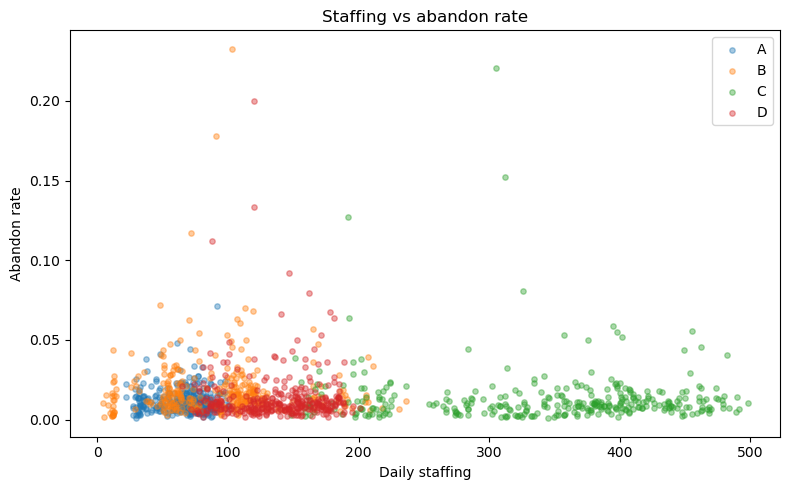

In [10]:
# does more staffing = lower abandon rate? checking
fig, ax = plt.subplots(figsize=(8, 5))
for center in ['A','B','C','D']:
    d = daily[center].dropna(subset=['daily_staffing', 'abandon_rate'])
    ax.scatter(d['daily_staffing'], d['abandon_rate'], label=center, alpha=0.4, s=15)
    # quick corr
    r = d['daily_staffing'].corr(d['abandon_rate'])
    print(f"Center {center} staffing vs abandon corr: {r:.3f}")

ax.set(title='Staffing vs abandon rate', xlabel='Daily staffing', ylabel='Abandon rate')
ax.legend()
plt.tight_layout()
plt.savefig('eda_plots/staffing_vs_abandon.png', dpi=150)
save_plot_to_s3('eda_plots/staffing_vs_abandon.png', 'outputs/eda/staffing_vs_abandon.png')
plt.show()

# comparing centers side by side

  -> s3://synchrony-callcenter/outputs/eda/center_comparison.png


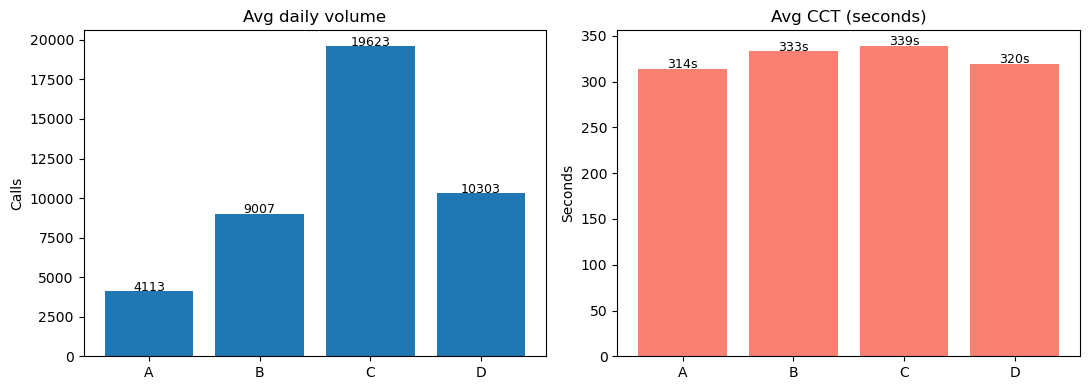

In [11]:
# side by side - volume and CCT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

centers = ['A','B','C','D']
avg_vol = [daily[c]['call_volume'].mean() for c in centers]
avg_cct = [daily[c]['CCT'].mean() for c in centers]

ax1.bar(centers, avg_vol)
ax1.set(title='Avg daily volume', ylabel='Calls')
for i, v in enumerate(avg_vol):
    ax1.text(i, v + 20, f'{v:.0f}', ha='center', fontsize=9)

ax2.bar(centers, avg_cct, color='salmon')
ax2.set(title='Avg CCT (seconds)', ylabel='Seconds')
for i, v in enumerate(avg_cct):
    ax2.text(i, v + 1, f'{v:.0f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_plots/center_comparison.png', dpi=150)
save_plot_to_s3('eda_plots/center_comparison.png', 'outputs/eda/center_comparison.png')
plt.show()

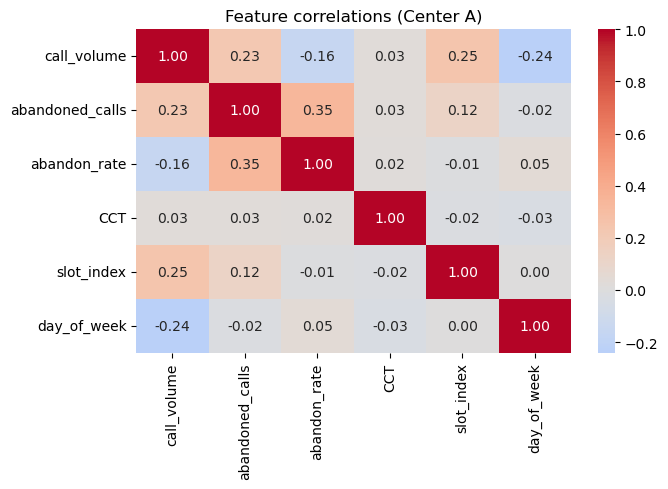

In [12]:
# quick correlation check on interval features - just center A, rest should be similar
df_a = interval['A']
num_cols = ['call_volume', 'abandoned_calls', 'abandon_rate', 'CCT', 'slot_index', 'day_of_week']
corr = df_a[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature correlations (Center A)')
plt.tight_layout()
plt.show()

takeaways before modeling:
- volume drops hard on weekends, need is_weekend feature
- intraday shape is pretty consistent across days - slot proportions approach should work
- abandon rate spikes during high-volume slots (mid-afternoon), prob a staffing issue
- CCT doesn't vary that much across centers, mostly 300-350s range
- D is the smallest center by volume, A is biggest